# Tooth instance segmentation (SAM) → trapezoid approximation → taper (conicity) measurement  
### + optional classifier: *prepared* (обточенный) vs *normal* (не обточенный)

This notebook is designed for **Colab** or **Kaggle**.

Pipeline:
1) **Instance segmentation with SAM** (Segment Anything) to get **a separate mask per tooth**  
2) For each tooth mask: **trapezoid approximation** + **taper angle / conicity** estimation  
3) Optional: **image classifier** to distinguish **prepared vs normal** teeth using crops derived from masks

Notes:
- Automatic SAM mask generation is strong, but you may need to tune filtering.
- Classifier section is minimal; for real accuracy you’ll want more labeled samples.


In [1]:
# =========================
# 0) Environment setup
# =========================
import os, sys, math, json, time
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"


torch: 2.10.0+cu128
cuda available: True


## 1) Install dependencies

Colab (recommended):
- `segment-anything` (Facebook Research)
- `opencv-python`
- `timm` (optional classifier)

Uncomment to install.


In [21]:
!pip -q install opencv-python matplotlib tqdm timm
!pip -q install git+https://github.com/facebookresearch/segment-anything.git


  Preparing metadata (setup.py) ... done


## 2) Download / provide SAM checkpoint

You need a SAM checkpoint (vit_h / vit_l / vit_b).
If download fails (host blocked), upload the file manually and set `SAM_CKPT_PATH`.


In [22]:
# Run this at the top of notebook, then restart runtime once
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [23]:
from pathlib import Path

CKPT_DIR = Path("./checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SAM_MODEL_TYPE = "vit_h"  # "vit_h" | "vit_l" | "vit_b"
SAM_CKPT_PATH = CKPT_DIR / "sam_vit_h_4b8939.pth"

if not SAM_CKPT_PATH.exists():
    print("Checkpoint not found:", SAM_CKPT_PATH)
    print("Attempting download (internet required)...")
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    try:
        import urllib.request
        urllib.request.urlretrieve(url, SAM_CKPT_PATH.as_posix())
        print("Downloaded to:", SAM_CKPT_PATH)
    except Exception as e:
        print("Download failed:", e)
        print("➡️ Upload the checkpoint and set SAM_CKPT_PATH.")
else:
    print("Checkpoint OK:", SAM_CKPT_PATH)


Checkpoint OK: checkpoints/sam_vit_h_4b8939.pth


In [24]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## 3) Load your image

Set `IMAGE_PATH` to your photo.


In [25]:
!ls -la "/content/drive/MyDrive/Стартап/Фотографии/" | grep IMG

-rw------- 1 root root 2165640 Oct 30 11:48 IMG_0329.JPG
-rw------- 1 root root 2737170 Oct 30 11:48 IMG_0330.JPG
-rw------- 1 root root 2658932 Oct 30 11:48 IMG_0331.JPG
-rw------- 1 root root 2687833 Oct 30 11:48 IMG_0332.JPG
-rw------- 1 root root 2677999 Oct 30 11:48 IMG_0333.JPG
-rw------- 1 root root 2582047 Oct 30 11:48 IMG_0334.JPG
-rw------- 1 root root 2303544 Oct 30 11:48 IMG_0335.JPG
-rw------- 1 root root 2597269 Oct 30 11:48 IMG_0336.JPG
-rw------- 1 root root 2614184 Oct 30 11:48 IMG_0337.JPG
-rw------- 1 root root 2447311 Oct 30 11:48 IMG_0338.JPG
-rw------- 1 root root 2485297 Oct 30 11:48 IMG_0339.JPG
-rw------- 1 root root 2893353 Oct 30 11:48 IMG_0340.JPG
-rw------- 1 root root 2333884 Oct 30 11:48 IMG_0341.JPG
-rw------- 1 root root 3133772 Oct 30 11:48 IMG_0342.JPG
-rw------- 1 root root 3036562 Oct 30 11:48 IMG_0343.JPG
-rw------- 1 root root 2555128 Oct 30 11:49 IMG_0344.JPG
-rw------- 1 root root 3192689 Oct 30 11:49 IMG_0345.JPG
-rw------- 1 root root 4507754 

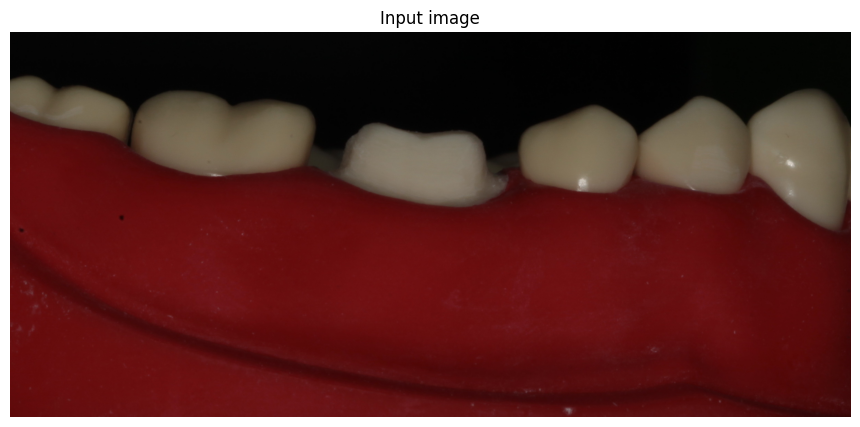

In [26]:
IMAGE_PATH = Path("/content/drive/MyDrive//Стартап/Фотографии/IMG_035.JPG")  # example path
assert IMAGE_PATH.exists(), f"Image not found: {IMAGE_PATH}"

image_bgr = cv2.imread(str(IMAGE_PATH))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14,5))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Input image")
plt.show()


## 4) Run SAM: automatic instance masks


In [30]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import cv2
import torch
import time
from pathlib import Path

# Параметры модели (должны быть заданы ранее, продублируем для надёжности)
SAM_MODEL_TYPE = "vit_h"
SAM_CKPT_PATH = Path("./checkpoints/sam_vit_h_4b8939.pth")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Функция изменения размера изображения (определена ранее)
def resize_longest(img, max_side=1536):
    h, w = img.shape[:2]
    s = max(h, w)
    if s <= max_side:
        return img
    scale = max_side / s
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

# Загрузка модели SAM
sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CKPT_PATH)
sam.to(device=device)

# Очистка кэша CUDA (опционально)
torch.cuda.empty_cache()

# Уменьшаем изображение
image_small = resize_longest(image_rgb, max_side=1536)

# Создаём генератор масок
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    points_per_batch=4,
    crop_n_layers=0,
    min_mask_region_area=100
)

# Засекаем время и запускаем генерацию
t0 = time.time()
with torch.inference_mode(), torch.autocast("cuda", dtype=torch.float16):
    masks = mask_generator.generate(image_small)

print(f"Generated {len(masks)} raw masks in {time.time()-t0:.1f}s")

Generated 18 raw masks in 2.9s


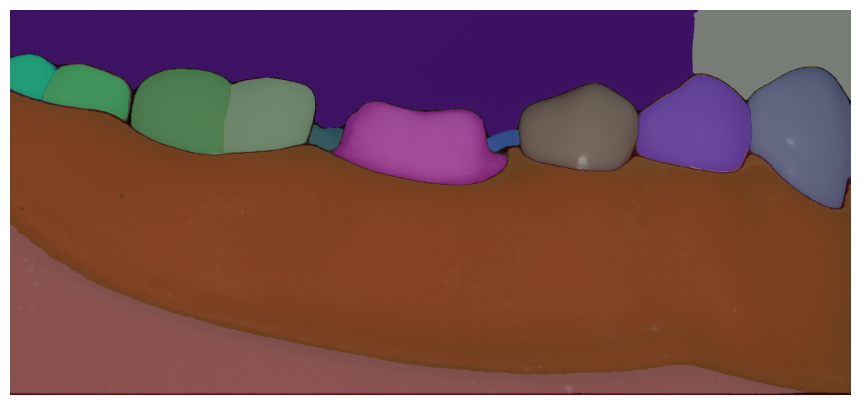

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_masks_on_image(img_rgb, masks, alpha=0.45, max_show=50, seed=42):
    rng = np.random.default_rng(seed)
    h, w = img_rgb.shape[:2]
    overlay = img_rgb.copy()

    for m in masks[:max_show]:
        seg = m["segmentation"].astype(np.uint8)  # from SAM
        if seg.shape != (h, w):
            seg = cv2.resize(seg, (w, h), interpolation=cv2.INTER_NEAREST)
        seg = seg.astype(bool)

        color = rng.integers(0, 255, size=3, dtype=np.uint8)
        overlay[seg] = (overlay[seg] * (1 - alpha) + color * alpha).astype(np.uint8)

    plt.figure(figsize=(14, 5))
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()
show_masks_on_image(image_rgb, masks, alpha=0.45, max_show=50)


## 5) Filter masks to keep teeth-like regions + de-duplicate overlaps


Filtered masks: 1
Instances kept: 1


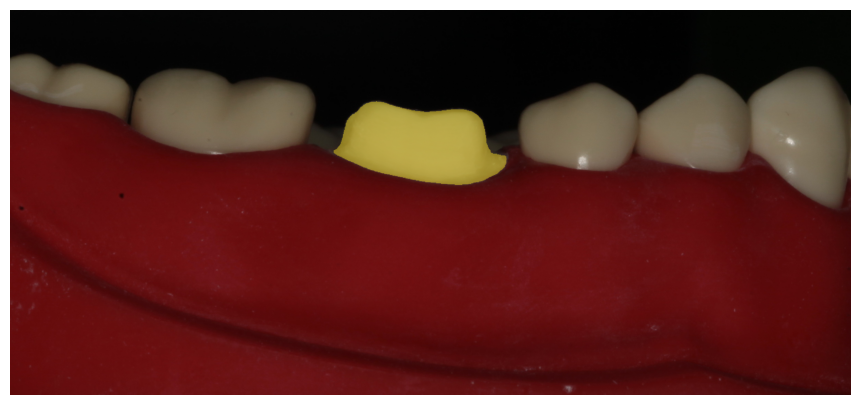

In [32]:
def mask_props(seg: np.ndarray):
    seg_u8 = (seg.astype(np.uint8) * 255)
    cnts, _ = cv2.findContours(seg_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    x, y, w, h = cv2.boundingRect(cnt)
    bbox_area = w * h
    if bbox_area == 0:
        return None
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull) if hull is not None else 0
    solidity = area / hull_area if hull_area > 0 else 0
    extent = area / bbox_area
    aspect = w / h if h > 0 else 0
    cy = y + h / 2.0
    return dict(
        area=area,
        x=x,
        y=y,
        w=w,
        h=h,
        cy=cy,
        bbox_area=bbox_area,
        solidity=solidity,
        extent=extent,
        aspect=aspect,
    )


def iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union + 1e-9)


def overlap_min(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    amin = min(a.sum(), b.sum())
    return float(inter) / float(amin + 1e-9)


def color_stats_hsv(hsv_img: np.ndarray, seg: np.ndarray):
    pix = hsv_img[seg.astype(bool)]
    if pix.size == 0:
        return dict(mean_h=0.0, mean_s=0.0, mean_v=0.0, orange_frac=0.0, dark_frac=1.0, white_frac=0.0)

    h = pix[:, 0].astype(np.float32)
    s = pix[:, 1].astype(np.float32)
    v = pix[:, 2].astype(np.float32)

    orange = (h >= 8) & (h <= 30) & (s >= 70) & (v >= 50)
    dark = v < 45
    tooth_white = (s < 85) & (v > 110)

    return dict(
        mean_h=float(h.mean()),
        mean_s=float(s.mean()),
        mean_v=float(v.mean()),
        orange_frac=float(orange.mean()),
        dark_frac=float(dark.mean()),
        white_frac=float(tooth_white.mean()),
    )


def select_instances(masks, iou_thresh=0.50, contain_thresh=0.85, max_instances=24):
    ms = sorted(masks, key=lambda m: (m["score"], m["props"]["area"]), reverse=True)
    kept = []
    for m in ms:
        seg = m["segmentation"]
        ok = True
        for k in kept:
            if iou(seg, k["segmentation"]) > iou_thresh:
                ok = False
                break
            if overlap_min(seg, k["segmentation"]) > contain_thresh:
                ok = False
                break
        if ok:
            kept.append(m)
        if len(kept) >= max_instances:
            break
    return kept


def resize_mask(seg: np.ndarray, out_hw):
    out_h, out_w = out_hw
    if seg.shape == (out_h, out_w):
        return seg.astype(bool)
    seg_u8 = seg.astype(np.uint8)
    return cv2.resize(seg_u8, (out_w, out_h), interpolation=cv2.INTER_NEAREST).astype(bool)


if not masks:
    filtered = []
    instances = []
    print("Filtered masks: 0")
    print("Instances kept: 0")
else:
    mask_h, mask_w = masks[0]["segmentation"].shape
    work_img = image_rgb
    if image_rgb.shape[:2] != (mask_h, mask_w):
        work_img = cv2.resize(image_rgb, (mask_w, mask_h), interpolation=cv2.INTER_AREA)

    work_hsv = cv2.cvtColor(work_img, cv2.COLOR_RGB2HSV)
    H, W = work_img.shape[:2]
    img_area = H * W

    filtered = []
    for m in masks:
        seg = m["segmentation"].astype(bool)
        if seg.shape != (H, W):
            seg = resize_mask(seg, (H, W))

        p = mask_props(seg)
        if p is None:
            continue

        area = p["area"]
        if area < max(250, 0.0002 * img_area):
            continue
        if area > 0.08 * img_area:
            continue
        if p["w"] < 12 or p["h"] < 12:
            continue
        if p["h"] > 0.35 * H:
            continue
        if p["aspect"] < 0.25 or p["aspect"] > 4.5:
            continue
        if p["solidity"] < 0.50 or p["extent"] < 0.22:
            continue
        if p["cy"] < 0.20 * H or p["cy"] > 0.82 * H:
            continue

        c = color_stats_hsv(work_hsv, seg)
        if c["dark_frac"] > 0.25:
            continue
        if c["orange_frac"] > 0.32:
            continue
        if c["mean_v"] < 55:
            continue

        m2 = dict(m)
        m2["segmentation"] = seg
        m2["props"] = p
        m2["color"] = c
        m2["score"] = (
            0.55 * float(m.get("predicted_iou", 0.0))
            + 0.35 * float(m.get("stability_score", 0.0))
            + 0.25 * c["white_frac"]
            + 0.15 * (1.0 - c["orange_frac"])
            + 0.10 * (1.0 - c["dark_frac"])
        )
        filtered.append(m2)

    instances_small = select_instances(filtered, iou_thresh=0.50, contain_thresh=0.85, max_instances=24)

    instances = []
    for m in instances_small:
        m2 = dict(m)
        seg_orig = resize_mask(m["segmentation"], image_rgb.shape[:2])
        m2["segmentation"] = seg_orig
        p_orig = mask_props(seg_orig)
        if p_orig is not None:
            m2["props"] = p_orig
        instances.append(m2)

    print("Filtered masks:", len(filtered))
    print("Instances kept:", len(instances))

show_masks_on_image(image_rgb, instances, max_show=80, seed=1)



## 6) Extract per-tooth crops


tooth_items: 1


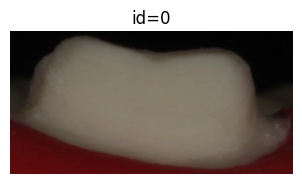

In [33]:
def crop_from_mask(img_rgb, seg, pad=12):
    ys, xs = np.where(seg>0)
    if xs.size == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    x0 = max(0, x0-pad); y0 = max(0, y0-pad)
    x1 = min(img_rgb.shape[1]-1, x1+pad); y1 = min(img_rgb.shape[0]-1, y1+pad)
    crop = img_rgb[y0:y1+1, x0:x1+1].copy()
    mask_crop = seg[y0:y1+1, x0:x1+1].copy()
    return crop, mask_crop, (int(x0),int(y0),int(x1),int(y1))

tooth_items = []
for idx, m in enumerate(instances):
    out = crop_from_mask(image_rgb, m["segmentation"].astype(np.uint8), pad=10)
    if out is None:
        continue
    crop, mask_crop, bbox = out
    tooth_items.append({"id": idx, "crop": crop, "mask_crop": mask_crop, "bbox": bbox})

print("tooth_items:", len(tooth_items))

cols = 6
rows = int(math.ceil(len(tooth_items)/cols)) if tooth_items else 1
plt.figure(figsize=(3*cols, 3*rows))
for i, t in enumerate(tooth_items):
    plt.subplot(rows, cols, i+1)
    plt.imshow(t["crop"])
    plt.axis("off")
    plt.title(f"id={t['id']}")
plt.tight_layout()
plt.show()


## 7) Trapezoid approximation + taper (конусность) measurement

Pragmatic 2D estimate:
- rotate mask to its principal axis (PCA)
- sample widths at top and bottom heights
- compute convergence angle

We also optionally fit left/right wall edge lines and sum their deviations from vertical.


In [49]:
import numpy as np
import cv2
import math
import matplotlib.pyplot as plt

# Словарь конусности: угол -> tan(угла)
taper_dict = {
    5: 0.0875,
    6: 0.1051,
    7: 0.1228,
    8: 0.1405,
    9: 0.1584,
    10: 0.1763,
    11: 0.1944,
    12: 0.2126,
    13: 0.2309,
    14: 0.2493,
    15: 0.2679,
    16: 0.2867,
    17: 0.3057,
    18: 0.3249,
    19: 0.3443,
    20: 0.3640,
    21: 0.3839,
    22: 0.4040,
    23: 0.4245,
    24: 0.4452,
    25: 0.4663,
    26: 0.4877,
    27: 0.5095,
    28: 0.5317
}

def find_closest_angle(ratio):
    """По заданному отношению (дельта/(2h)) возвращает ближайший угол из словаря."""
    if ratio <= taper_dict[5]:
        return 5
    if ratio >= taper_dict[28]:
        return 28
    # Ищем ближайшее значение
    closest_angle = min(taper_dict.keys(), key=lambda angle: abs(taper_dict[angle] - ratio))
    return closest_angle

def widths_by_row(mask01: np.ndarray):
    """Для каждой строки (y) находит левую и правую границы маски и её ширину."""
    h, w = mask01.shape
    widths = np.zeros(h, dtype=np.int32)
    lefts = np.full(h, -1, dtype=np.int32)
    rights = np.full(h, -1, dtype=np.int32)
    for y in range(h):
        xs = np.where(mask01[y, :] > 0)[0]
        if xs.size:
            lefts[y] = xs.min()
            rights[y] = xs.max()
            widths[y] = rights[y] - lefts[y] + 1
    return lefts, rights, widths

def trapezoid_taper_no_rot(mask01: np.ndarray, top_q=0.25, bot_q=0.80, smooth=7):
    """
    Вычисляет угол конусности зуба без предварительного поворота.
    Предполагается, что зуб уже ориентирован вертикально.
    Возвращает словарь с результатами, включая угол из словаря.
    """
    # Получаем ширины по строкам
    lefts, rights, widths = widths_by_row(mask01)
    ys = np.where(widths > 0)[0]
    if ys.size < 10:
        return None

    y0, y1 = ys.min(), ys.max()
    height = y1 - y0 + 1

    # Сглаживание ширины скользящим средним
    w_s = widths.astype(np.float32)
    if smooth > 1:
        k = np.ones(smooth, dtype=np.float32) / smooth
        w_s_valid = np.convolve(w_s[ys], k, mode="same")
        w_s[ys] = w_s_valid

    # Выбираем верхнюю и нижнюю линии
    y_top = int(y0 + top_q * height)
    y_bot = int(y0 + bot_q * height)
    y_top = int(np.clip(y_top, y0, y1))
    y_bot = int(np.clip(y_bot, y0, y1))
    if y_bot <= y_top:
        return None

    w_top = float(w_s[y_top])
    w_bot = float(w_s[y_bot])
    h_eff = float(y_bot - y_top)

    # Вычисляем отношение (дельта ширины) / (2 * высота)
    delta = abs(w_bot - w_top)
    ratio = delta / (2.0 * h_eff + 1e-9)

    # Находим ближайший угол из словаря
    angle_from_dict = find_closest_angle(ratio)

    # Альтернативная оценка по левой и правой стенкам (оставим как есть)
    ys_fit = np.arange(y_top, y_bot + 1)
    xL = lefts[ys_fit]
    xR = rights[ys_fit]
    valid = (xL >= 0) & (xR >= 0)
    ys_fit = ys_fit[valid]
    xL = xL[valid].astype(np.float32)
    xR = xR[valid].astype(np.float32)

    left_wall_deg = None
    right_wall_deg = None
    conicity_lr_deg = None
    if ys_fit.size >= 8:
        aL, bL = np.polyfit(ys_fit, xL, 1)
        aR, bR = np.polyfit(ys_fit, xR, 1)
        left_wall_deg = math.degrees(math.atan(abs(aL)))
        right_wall_deg = math.degrees(math.atan(abs(aR)))
        conicity_lr_deg = left_wall_deg + right_wall_deg

    return {
        "y_top": y_top,
        "y_bot": y_bot,
        "w_top": w_top,
        "w_bot": w_bot,
        "h_eff": h_eff,
        "ratio": ratio,
        "angle_from_dict": angle_from_dict,
        "left_wall_deg": left_wall_deg,
        "right_wall_deg": right_wall_deg,
        "conicity_lr_deg": conicity_lr_deg,
        "lefts": lefts,
        "rights": rights,
        "mask": mask01,
    }

def visualize_trapezoid_no_rot(crop_rgb, mask01, result):
    """
    Визуализация без поворота: контур зуба и две горизонтальные линии.
    """
    y_top = result["y_top"]
    y_bot = result["y_bot"]
    lefts = result["lefts"]
    rights = result["rights"]

    vis = crop_rgb.copy()
    # Рисуем контур маски
    cnts, _ = cv2.findContours((mask01 * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis, cnts, -1, (0, 255, 0), 2)

    # Рисуем линии на выбранных уровнях
    for y, col in [(y_top, (255, 0, 0)), (y_bot, (0, 0, 255))]:
        if lefts[y] >= 0 and rights[y] >= 0:
            cv2.line(vis, (int(lefts[y]), int(y)), (int(rights[y]), int(y)), col, 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(vis)
    plt.axis("off")
    title = f"Angle from dict = {result['angle_from_dict']}° (ratio={result['ratio']:.4f})"
    if result["conicity_lr_deg"] is not None:
        title += f" | LR={result['conicity_lr_deg']:.2f}°"
    plt.title(title)
    plt.show()

In [50]:
taper_results = []
for t in tooth_items:
    res = trapezoid_taper_no_rot(t["mask_crop"].astype(np.uint8), top_q=0.15, bot_q=0.65, smooth=7)
    taper_results.append(res)

for t, res in zip(tooth_items, taper_results):
    if res is None:
        print(f"id={t['id']}: taper could not be computed")
    else:
        print(f"id={t['id']}: angle={res['angle_from_dict']}° (ratio={res['ratio']:.4f}) | "
              f"w_top={res['w_top']:.1f} w_bot={res['w_bot']:.1f} h={res['h_eff']:.1f}")



id=0: angle=28° (ratio=0.5222) | w_top=353.1 w_bot=480.6 h=122.0


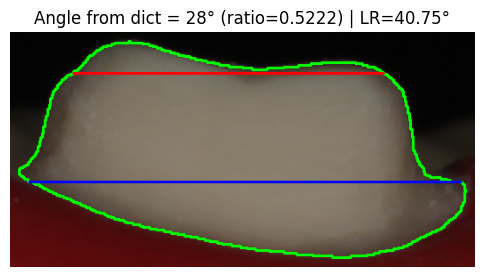

In [51]:
# Visualize a few teeth with overlay
show_n = min(8, len(tooth_items))
for i in range(show_n):
    t = tooth_items[i]
    res = taper_results[i]
    if res is None:
        continue
    if res is not None:
       visualize_trapezoid_no_rot(t["crop"], t["mask_crop"].astype(np.uint8), res)

## 8) Prepared tooth candidate ranking (heuristic)

Sort by conicity descending.


Top candidates by conicity(width):
  id=0: 20.75°
  id=1: 16.99°
  id=2: 6.13°


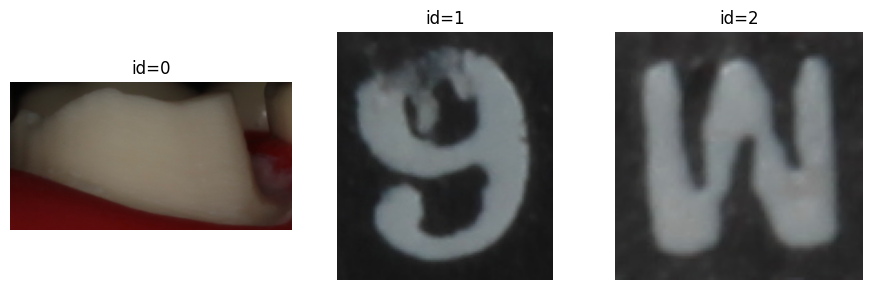

In [ ]:
ranked = []
for t, res in zip(tooth_items, taper_results):
    if res is None:
        continue
    ranked.append((res["conicity_width_deg"], t["id"]))
ranked.sort(reverse=True)

print("Top candidates by conicity(width):")
for score, tid in ranked[:10]:
    print(f"  id={tid}: {score:.2f}°")

K = min(6, len(ranked))
plt.figure(figsize=(3*K, 3))
for i in range(K):
    _, tid = ranked[i]
    t = next(x for x in tooth_items if x["id"] == tid)
    plt.subplot(1, K, i+1)
    plt.imshow(t["crop"])
    plt.axis("off")
    plt.title(f"id={tid}")
plt.tight_layout()
plt.show()


## 9) Optional classifier: prepared vs normal

Provide labels via dict:
- 1 → prepared (обточенный)
- 0 → normal (не обточенный)


In [ ]:
# --------- Manual labels ----------
labels = {}  # e.g. {3:1, 0:0, 1:0, 2:0}

print("Labeled samples:", sum(1 for t in tooth_items if t["id"] in labels))


Labeled samples: 0


In [ ]:
# Train a small ResNet18 classifier (requires timm)
import timm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

def preprocess_crop(img_rgb, size=224):
    img = cv2.resize(img_rgb, (size, size), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32)/255.0
    img = np.transpose(img, (2,0,1))  # CHW
    return img

class ToothCropDataset(Dataset):
    def __init__(self, items, labels_map, size=224):
        self.samples = []
        for t in items:
            tid = t["id"]
            if tid in labels_map:
                self.samples.append((t["crop"], labels_map[tid]))
        self.size = size
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img, y = self.samples[idx]
        x = preprocess_crop(img, self.size)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

def train_classifier(tooth_items, labels_map, epochs=10, lr=1e-4, batch_size=4):
    ds = ToothCropDataset(tooth_items, labels_map, size=224)
    if len(ds) < 6:
        print("Need at least ~6 labeled samples for a meaningful train/val split.")
        return None

    idxs = np.arange(len(ds))
    np.random.seed(0); np.random.shuffle(idxs)
    n_val = max(1, int(0.2*len(ds)))
    val_idxs = idxs[:n_val]; tr_idxs = idxs[n_val:]

    tr_loader = DataLoader(torch.utils.data.Subset(ds, tr_idxs.tolist()), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(torch.utils.data.Subset(ds, val_idxs.tolist()), batch_size=batch_size, shuffle=False)

    model = timm.create_model("resnet18", pretrained=True, num_classes=2).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    def eval_loader(loader):
        model.eval()
        tot, corr, loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(device); yb = yb.to(device)
                logits = model(xb)
                loss = crit(logits, yb)
                corr += (logits.argmax(1)==yb).sum().item()
                tot += yb.numel()
                loss_sum += loss.item()*yb.numel()
        return loss_sum/max(1,tot), corr/max(1,tot)

    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in tr_loader:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        tr_loss, tr_acc = eval_loader(tr_loader)
        va_loss, va_acc = eval_loader(val_loader)
        print(f"epoch {ep:02d} | tr loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")
    return model

clf_model = train_classifier(tooth_items, labels, epochs=10) if len(labels)>0 else None


In [ ]:
def predict_all(model, tooth_items):
    model.eval()
    preds = {}
    with torch.no_grad():
        for t in tooth_items:
            x = preprocess_crop(t["crop"], 224)
            xb = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1)[0,1].item()  # P(prepared)
            preds[t["id"]] = prob
    return preds

if clf_model is not None:
    probs = predict_all(clf_model, tooth_items)
    for tid, p in sorted(probs.items(), key=lambda kv: kv[1], reverse=True)[:10]:
        print(f"id={tid}: P(prepared)={p:.3f}")
else:
    probs = {t['id']: 0.0 for t in tooth_items}
    print("Classifier not trained (no labels).")


Classifier not trained (no labels).


## 10) Combine taper + classifier

Simple combined score (tune weights as needed).


In [ ]:
combined = []
for t, res in zip(tooth_items, taper_results):
    if res is None:
        continue
    tid = t["id"]
    con = res["conicity_width_deg"]
    pprep = probs.get(tid, 0.0)
    score = 0.6*(con/20.0) + 0.4*pprep
    combined.append((score, tid, con, pprep))

combined.sort(reverse=True)
print("Top combined candidates:")
for score, tid, con, pprep in combined[:10]:
    print(f"  id={tid} | score={score:.3f} | conicity={con:.2f}° | P(prepared)={pprep:.3f}")


Top combined candidates:
  id=1 | score=1.457 | conicity=48.58° | P(prepared)=0.000
  id=0 | score=0.096 | conicity=3.19° | P(prepared)=0.000


## 11) Export results to JSON


In [ ]:
out = []
for t, res in zip(tooth_items, taper_results):
    tid = t["id"]
    item = {"id": tid, "bbox_xyxy": t["bbox"]}
    if res is not None:
        item.update({
            "conicity_width_deg": res["conicity_width_deg"],
            "conicity_lr_deg": res["conicity_lr_deg"],
            "w_top": res["w_top"],
            "w_bot": res["w_bot"],
            "h_eff": res["h_eff"],
        })
    item["p_prepared"] = float(probs.get(tid, 0.0))
    out.append(item)

RESULTS_PATH = Path("./tooth_results.json")
RESULTS_PATH.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", RESULTS_PATH.resolve())


Saved: /content/tooth_results.json


## Next steps

- If SAM produces merged teeth, increase `points_per_side`, lower `pred_iou_thresh`, and/or tweak geometric filters.  
- For more robust taper: use calibrated camera geometry and measure in mm; optionally fit side-wall lines only in mid-third.  
- For classifier: label many more crops across images; add augmentations; consider a proper train/val split across patients/images.
